# House Price Prediction using Linear Regression

## Objective
The objective of this project is to develop a Linear Regression model that predicts house prices based on housing characteristics such as area, bedrooms, bathrooms, parking, furnishing status, and other relevant features. The dataset was collected from Kaggle and preprocessed before model training and evaluation.

## Import Required Libraries
Importing the necessary Python libraries for data analysis, visualization, preprocessing, and machine learning.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset
Loading the Housing dataset into a Pandas DataFrame.

In [32]:
df = pd.read_csv('C:\\Users\\rupes\\OneDrive\\Desktop\\Python projects\\house_price_prediction\\data\\Housing.csv')

## Dataset Preview
Displaying the first five records to understand the structure of the dataset.

In [33]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Dataset Dimensions
Checking the number of rows and columns in the dataset.

In [34]:
df.shape

(545, 13)

## Dataset Information
Inspecting data types and verifying the presence of non-null values.

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## Missing Value Analysis
Checking whether the dataset contains missing values.

In [36]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Statistical Summary
Generating summary statistics for numerical features.

In [37]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Feature Analysis
Listing all available features in the dataset.

In [38]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

## Categorical Feature Exploration
Analyzing categorical features and their value distributions before encoding.

In [39]:
'''selecting columns one at a time''' 
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts()) 
'''to know the unique values in the categorical columns'''



mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64

basement
basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea
prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


'to know the unique values in the categorical columns'

## Data Preprocessing
Converting categorical variables into numerical format using One-Hot Encoding.

In [40]:
df_encoded = pd.get_dummies(df, drop_first=True)

## Encoded Dataset Preview
Verifying the transformed dataset after encoding.

In [41]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [42]:
df_encoded.shape

(545, 14)

## Feature and Target Selection
Separating input features (X) and target variable (Y).

- X = Independent Variables
- y = House Price (Target Variable)

In [43]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

print(X.shape)
print(y.shape)

(545, 13)
(545,)


## Train-Test Split
Splitting the dataset into training and testing sets using an 80:20 ratio.

In [44]:
from sklearn.model_selection import train_test_split 

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(436, 13)
(109, 13)
(436,)
(109,)


## Model Training
Creating and training the Linear Regression model using the training dataset.

In [46]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred[:5])

[5164653.90033967 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725955]


## House Price Prediction
Generating predictions for the test dataset and comparing actual and predicted values.

In [47]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06
5,4900000,3.532275e+06
6,5250000,5.611775e+06
7,4543000,6.368146e+06
8,2450000,2.722857e+06
9,3353000,2.629406e+06


## Model Evaluation
Evaluating model performance using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 970043.4039201637
MSE: 1754318687330.6643
RMSE: 1324506.9600914388
R2 Score: 0.6529242642153184


## Actual vs Predicted Price Visualization
Visualizing the relationship between actual house prices and predicted house prices.

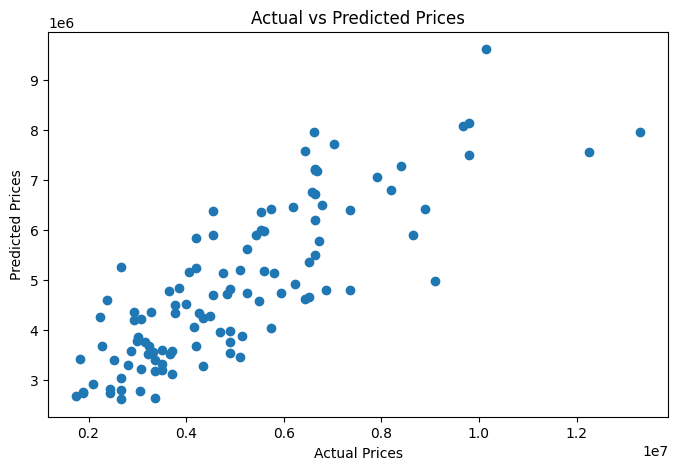

In [49]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

## Correlation Heatmap
Analyzing relationships between features and identifying factors that influence house prices.

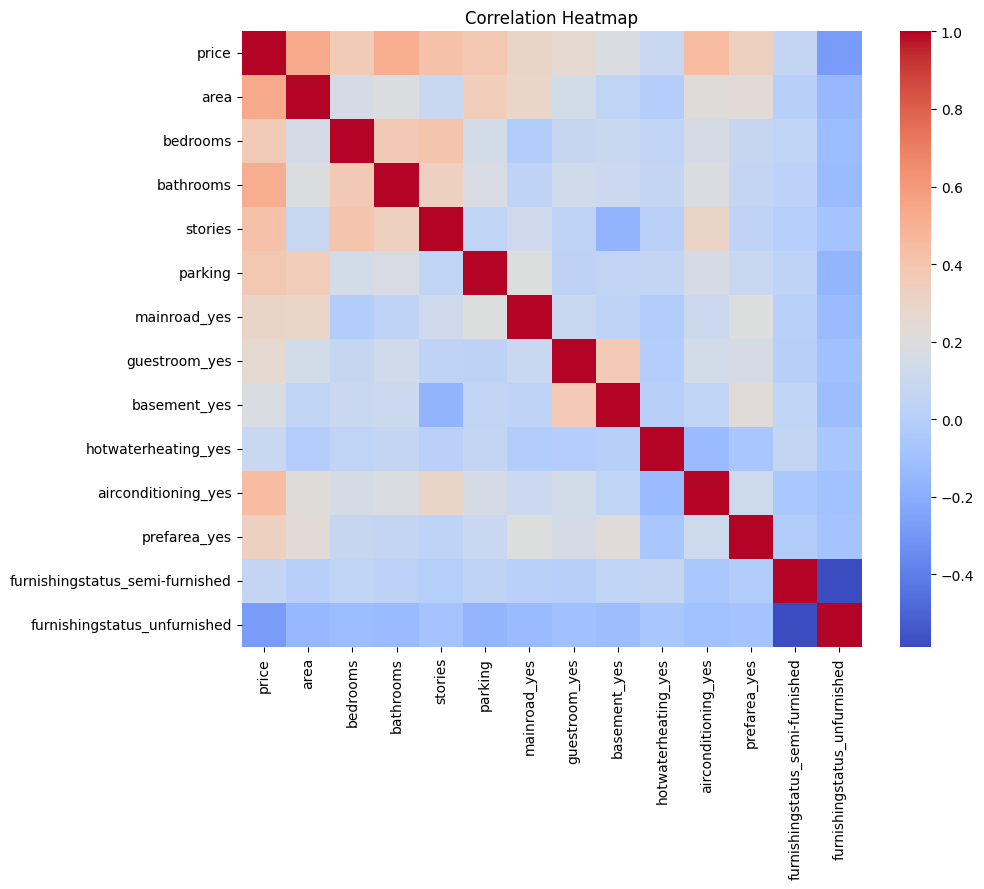

In [50]:
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Conclusion
A Linear Regression model was successfully developed for house price prediction using housing-related features such as area, bedrooms, bathrooms, stories, parking, furnishing status, and other relevant factors.

The dataset was preprocessed using One-Hot Encoding to handle categorical variables. The model was trained and evaluated on unseen data, achieving an R² Score of approximately 0.65, indicating reasonable predictive performance.

The analysis showed that features such as area, bathrooms, stories, and parking have a positive influence on house prices. Overall, this project demonstrates the complete machine learning workflow, including data preprocessing, model training, evaluation, and visualization.